#  Tech Assessment: Weather Trend Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

In [2]:
# read csv
df = pd.read_csv("./data/GlobalWeatherRepository.csv")
print(df.shape)
df.sample(6)

(130003, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
45507,Germany,Berlin,52.5167,13.4000,Europe/Berlin,1736158500,2025-01-06 11:15,10.3,50.5,Sunny,...,23.125,28.120,2,2,08:16 AM,04:09 PM,11:12 AM,No moonset,First Quarter,38
112668,Bulgaria,Sofia,42.6833,23.3167,Europe/Sofia,1765955700,2025-12-17 09:15,-4.7,23.5,Freezing fog,...,40.450,42.650,3,4,07:52 AM,04:54 PM,05:37 AM,02:39 PM,Waning Crescent,9
93326,Turkey,Ankara,39.9272,32.8644,Europe/Istanbul,1757319300,2025-09-08 11:15,18.3,64.9,Moderate or heavy rain with thunder,...,22.940,31.635,2,2,06:23 AM,07:09 PM,07:30 PM,06:54 AM,Waning Gibbous,100
90377,Sierra Leone,Freetown,8.4900,-13.2342,Africa/Freetown,1756022400,2025-08-24 08:00,23.3,74.0,Heavy rain,...,9.805,14.800,1,1,06:45 AM,07:05 PM,07:40 AM,08:06 PM,Waxing Crescent,1
27963,Bahamas,Nassau,25.0833,-77.3500,America/Nassau,1728380700,2024-10-08 05:45,28.3,83.0,Thundery outbreaks in nearby,...,7.400,13.505,1,1,07:05 AM,06:48 PM,12:15 PM,10:40 PM,Waxing Crescent,23
79388,Israel,Jerusalem,31.7800,35.2300,Asia/Jerusalem,1751186700,2025-06-29 11:45,33.3,91.9,Sunny,...,21.090,30.525,2,2,05:37 AM,07:49 PM,09:33 AM,11:01 PM,Waxing Crescent,14


In [3]:
# display df stats
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,130003.000000,130003.000000,1.300030e+05,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,...,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000
mean,19.203631,21.976354,1.744777e+09,21.404561,70.529999,8.042931,12.947448,168.959509,1014.097521,29.945664,...,18.295989,468.990972,58.452398,15.142142,10.531454,24.463289,48.967420,1.706922,2.625162,49.725629
std,24.420627,65.788604,1.669083e+07,9.688223,17.438649,7.297507,11.741068,103.572696,10.497520,0.309957,...,13.922968,769.933810,30.962557,23.987244,36.312698,37.398961,151.004804,0.946519,2.461476,35.020085
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730365e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,207.200000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.744794e+09,24.000000,75.300000,6.900000,11.200000,161.000000,1014.000000,29.930000,...,15.400000,299.700000,55.100000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759219e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,24.300000,467.300000,74.000000,17.575000,8.510000,28.050000,41.950000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.773730e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [4]:
# display all columns
df.columns.values.tolist()

['country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'last_updated',
 'temperature_celsius',
 'temperature_fahrenheit',
 'condition_text',
 'wind_mph',
 'wind_kph',
 'wind_degree',
 'wind_direction',
 'pressure_mb',
 'pressure_in',
 'precip_mm',
 'precip_in',
 'humidity',
 'cloud',
 'feels_like_celsius',
 'feels_like_fahrenheit',
 'visibility_km',
 'visibility_miles',
 'uv_index',
 'gust_mph',
 'gust_kph',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index',
 'sunrise',
 'sunset',
 'moonrise',
 'moonset',
 'moon_phase',
 'moon_illumination']

# Basic Assessment

## Data Cleaning & Preprocessing
* Handle missing values
* outliers
* normalize data

### Missing Values

In [5]:
# Handle missing values
missing_count = df.isnull().sum()

print("Missing values per column")
missing_count[missing_count > 0]

# if missing values, either drop rows with them / replace missing values with mean, median or relevant mode / fill missing values with closest values in column / interpolation technique 

Missing values per column


Series([], dtype: int64)

!!! NO MISSING VALUES

### Outliers
* Outliers that may vary - be careful
    * tmp, humidity, pressure, wind, UV, precipitation 
    * condition text, wind direction, air quality indices
* extreme real event vs real outlier

In [6]:
# IQR DOES NOT WORK (24,163 outliers)
# Hard limit based on meteorology like max and min celsius known

domain_limits = {
    'temperature_celsius': (-90, 60),   # record low ~-89.2°C, high ~56.7°C
    'wind_kph':            (0, 408),    # world record ~408 kph
    'pressure_mb':         (870, 1085), # typhoon lows ~870, highs ~1085
    'precip_mm':           (0, 1400),   # daily record ~1825mm
}

df_original = df.copy()  # preserve original for anomaly comparison later

impossible_counts = {}
for col, (lower, upper) in domain_limits.items():
    n_impossible = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    impossible_counts[col] = n_impossible
    df[col] = df[col].clip(lower=lower, upper=upper)
    if n_impossible > 0:
        print(f"{col}: Clipped {n_impossible} physically impossible values.")
    else:
        print(f"{col}: No physically impossible values found.")

print("\nDomain clipping complete. Statistical anomaly detection → Advanced EDA.")


temperature_celsius: No physically impossible values found.
wind_kph: Clipped 1 physically impossible values.
pressure_mb: Clipped 2 physically impossible values.
precip_mm: No physically impossible values found.

Domain clipping complete. Statistical anomaly detection → Advanced EDA.


### Advanced EDA - Outliers

In [7]:
from sklearn.ensemble import IsolationForest
import matplotlib.patches as mpatches

ANOMALY_FEATURES = [
    'temperature_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'precip_mm', 'uv_index', 'cloud',
    'air_quality_PM2.5', 'air_quality_Carbon_Monoxide'
]

# Work on the full cleaned df (before train/test split and scaling)
# Use df_original domain-clipped values (already stored in df at this point)
anomaly_df = df[['last_updated', 'location_name', 'country', 'latitude', 'longitude'] + ANOMALY_FEATURES].copy()
anomaly_df['last_updated'] = pd.to_datetime(anomaly_df['last_updated'])

print(f"Anomaly detection dataset: {anomaly_df.shape}")

Anomaly detection dataset: (130003, 14)


In [8]:
# ISOLATION FOREST
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# Fill any NaNs in features with median before fitting
feat_matrix = anomaly_df[ANOMALY_FEATURES].fillna(anomaly_df[ANOMALY_FEATURES].median())

anomaly_df['iso_score'] = iso_forest.fit_predict(feat_matrix)   # -1 = anomaly, 1 = normal
anomaly_df['iso_anomaly'] = (anomaly_df['iso_score'] == -1)
anomaly_df['iso_decision_score'] = iso_forest.decision_function(feat_matrix)  # lower = more anomalous

n_iso = anomaly_df['iso_anomaly'].sum()
print(f"Isolation Forest flagged: {n_iso} anomalies ({n_iso/len(anomaly_df)*100:.2f}% of dataset)")

Isolation Forest flagged: 2601 anomalies (2.00% of dataset)


In [9]:
# PER-CITY Z-SCORE FLAGGING 
# Flags readings that are extreme - relative to that city's own climate.

Z_THRESHOLD = 3.5

def city_zscore_flag(group, cols, threshold):
    flags = pd.Series(False, index=group.index)
    for col in cols:
        mean = group[col].mean()
        std  = group[col].std()
        if std > 0:
            z = (group[col] - mean) / std
            flags |= z.abs() > threshold
    return flags

city_z_cols = ['temperature_celsius', 'pressure_mb', 'wind_kph', 'precip_mm']

anomaly_df['city_z_anomaly'] = (
    anomaly_df.groupby('location_name', group_keys=False)
    .apply(lambda g: city_zscore_flag(g, city_z_cols, Z_THRESHOLD))
)

n_city_z = anomaly_df['city_z_anomaly'].sum()
print(f"Per-city Z-score flagged: {n_city_z} anomalies ({n_city_z/len(anomaly_df)*100:.2f}%)")

# caught by BOTH methods for high-confidence
anomaly_df['both_methods'] = anomaly_df['iso_anomaly'] & anomaly_df['city_z_anomaly']
n_both = anomaly_df['both_methods'].sum()
print(f"Flagged by BOTH methods:  {n_both} anomalies ({n_both/len(anomaly_df)*100:.2f}%) ← high-confidence")

Per-city Z-score flagged: 2365 anomalies (1.82%)
Flagged by BOTH methods:  568 anomalies (0.44%) ← high-confidence


/var/folders/g6/f1gwjy8559q53gsjmv0zgf0m0000gn/T/ipykernel_17425/2453763047.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: city_zscore_flag(g, city_z_cols, Z_THRESHOLD))


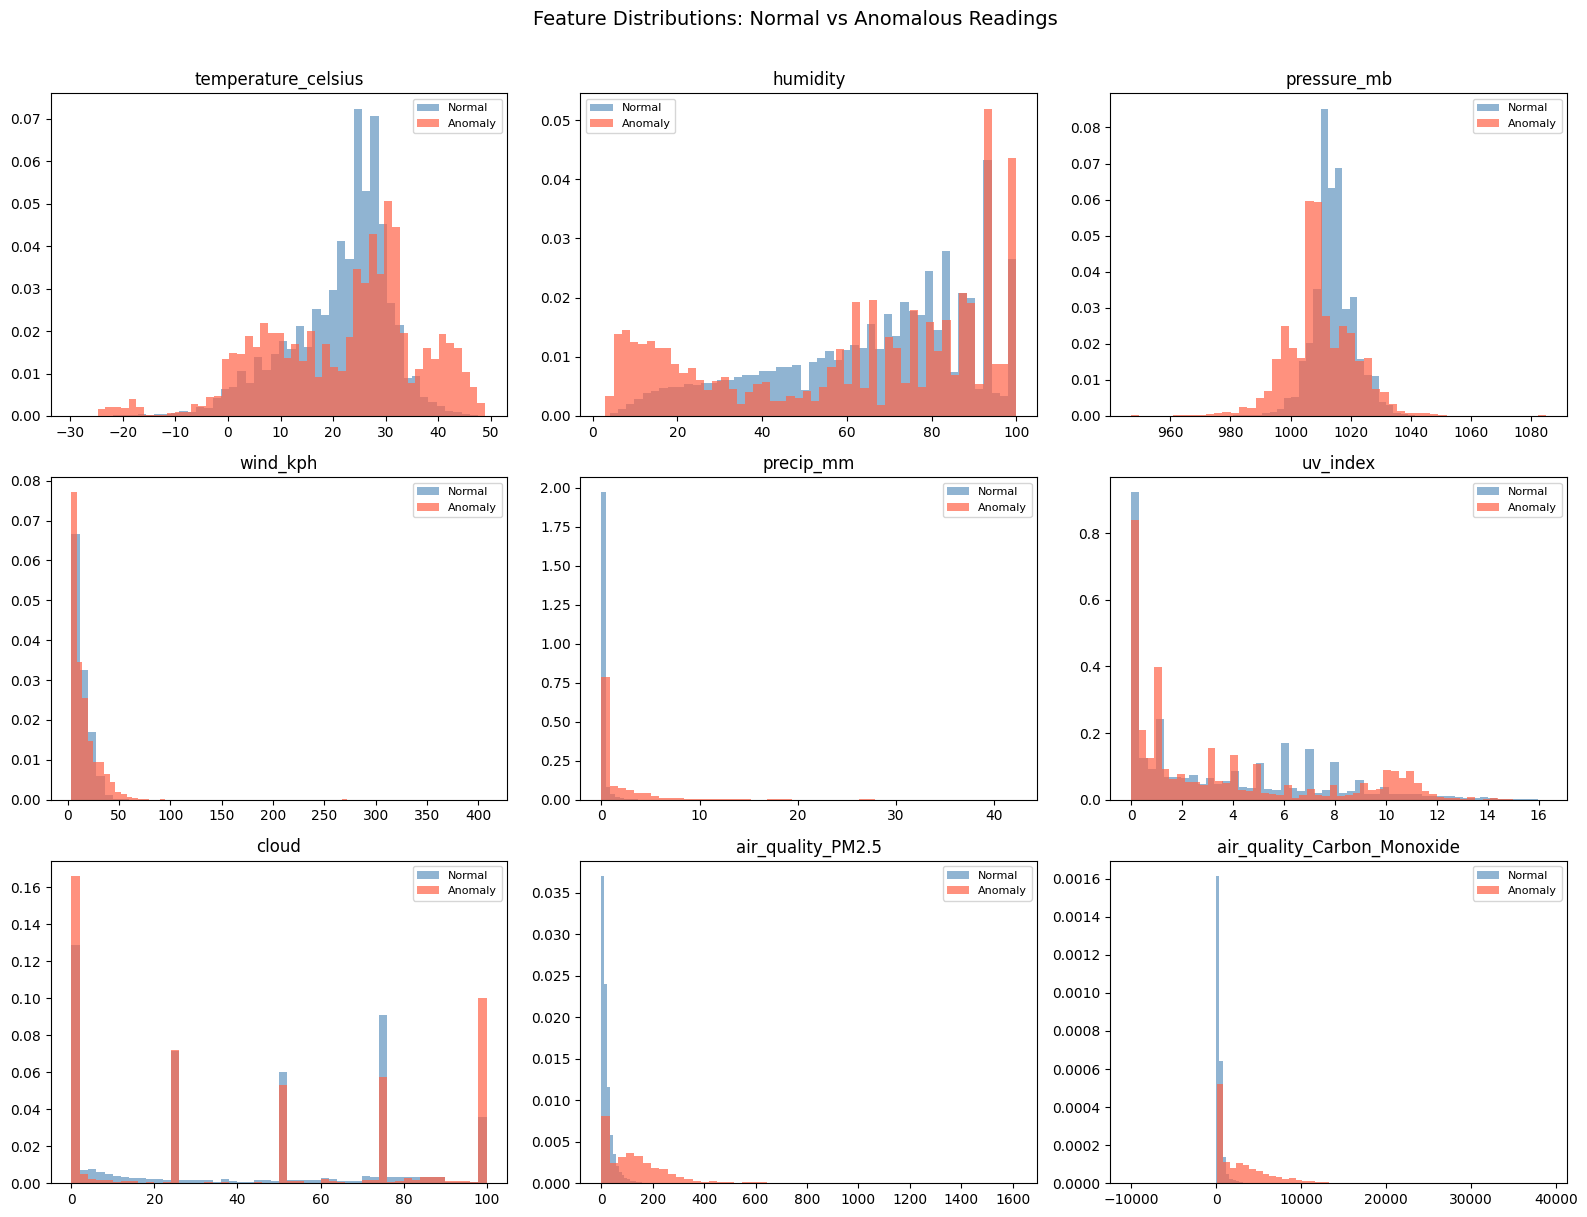

In [10]:
# ANOMALIES ACROSS FEATURES


normal   = anomaly_df[~anomaly_df['iso_anomaly']]
anomalies = anomaly_df[anomaly_df['iso_anomaly']]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(ANOMALY_FEATURES):
    axes[i].hist(normal[col].dropna(), bins=50, color='steelblue',
                 alpha=0.6, label='Normal', density=True)
    axes[i].hist(anomalies[col].dropna(), bins=50, color='tomato',
                 alpha=0.7, label='Anomaly', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Normal vs Anomalous Readings', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# SUMMARY TABLE: High-confidence anomalies (both methods) 

high_conf = anomaly_df[anomaly_df['both_methods']].copy()
high_conf_display = (
    high_conf[['last_updated', 'country', 'location_name'] + ANOMALY_FEATURES + ['iso_decision_score']]
    .sort_values('iso_decision_score')   # most extreme first
    .head(20)
)

print(f"\nTop 20 most extreme anomalies (flagged by both methods):")
print(high_conf_display.to_string(index=False))


Top 20 most extreme anomalies (flagged by both methods):
       last_updated     country  location_name  temperature_celsius  humidity  pressure_mb  wind_kph  precip_mm  uv_index  cloud  air_quality_PM2.5  air_quality_Carbon_Monoxide  iso_decision_score
2024-06-13 10:00:00       Chile       Santiago                 11.2        94       1010.0       9.0       4.41       3.0    100            338.500                     5607.600           -0.168384
2024-05-22 21:15:00   Indonesia        Jakarta                 29.0        79       1009.0      15.1       2.49       1.0     50            384.800                    18585.199           -0.140638
2024-09-07 19:00:00     Vietnam          Hanoi                 26.2        89        985.0      56.2      27.82       1.0    100              9.435                      562.400           -0.130616
2024-05-22 10:15:00       Chile       Santiago                 10.0        94       1015.0      11.2       0.96       4.0    100            579.300       

In [12]:
# check stats
stats_check = []
for col in ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']:
    mean = df[col].mean()
    std = df[col].std()
    stats_check.append({
        'Feature': col,
        'Mean': round(mean, 2),
        'Std Dev': round(std, 2),
        'Lower Bound (Mean - 3σ)': round(mean - 3*std, 2),
        'Upper Bound (Mean + 3σ)': round(mean + 3*std, 2),
        'Max Value': df[col].max()
    })

pd.DataFrame(stats_check)

,Feature,Mean,Std Dev,Lower Bound (Mean - 3σ),Upper Bound (Mean + 3σ),Max Value
0,temperature_celsius,21.40,9.69,-7.66,50.47,49.20
1,wind_kph,12.93,8.49,-12.55,38.40,408.00
2,pressure_mb,1014.07,7.03,992.98,1035.16,1085.00
3,precip_mm,0.14,0.56,-1.56,1.83,42.24


### Normalize Data
* differente scales for data
* XGBoost + LSTM? + Sarimax for seasonality
* XGBoost - NO normalization need (tree based)
* LSTM/SARIMAX - Standard Z-score normalization 

In [13]:
# time sorting
df = df.sort_values('last_updated')

# data split 80 / 20
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# feat to scale
cols_to_scale = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity']

# log transform precip_mm before scaling (too skewed)
train_df['precip_mm'] = np.log1p(train_df['precip_mm'])
test_df['precip_mm'] = np.log1p(test_df['precip_mm'])

# fit on train, transform on both
scaler = StandardScaler()
train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

print(f"Split complete. Train set: {train_df.shape[0]} rows | Test set: {test_df.shape[0]} rows")

Split complete. Train set: 104002 rows | Test set: 26001 rows


## Exploratory Data Analysis (EDA)

### Perform basic EDA to uncover the trends, correlations, and patterns.
* feature relationship
* autocorr (ACF) and partial autocorr (PACF)
* spearman heatmap - non linear relation -
* decompose target var into its trend
* Plotting rolling means/standard deviations and performing the Augmented Dickey-Fuller (ADF) test - SARIMAX requires data to be stationary

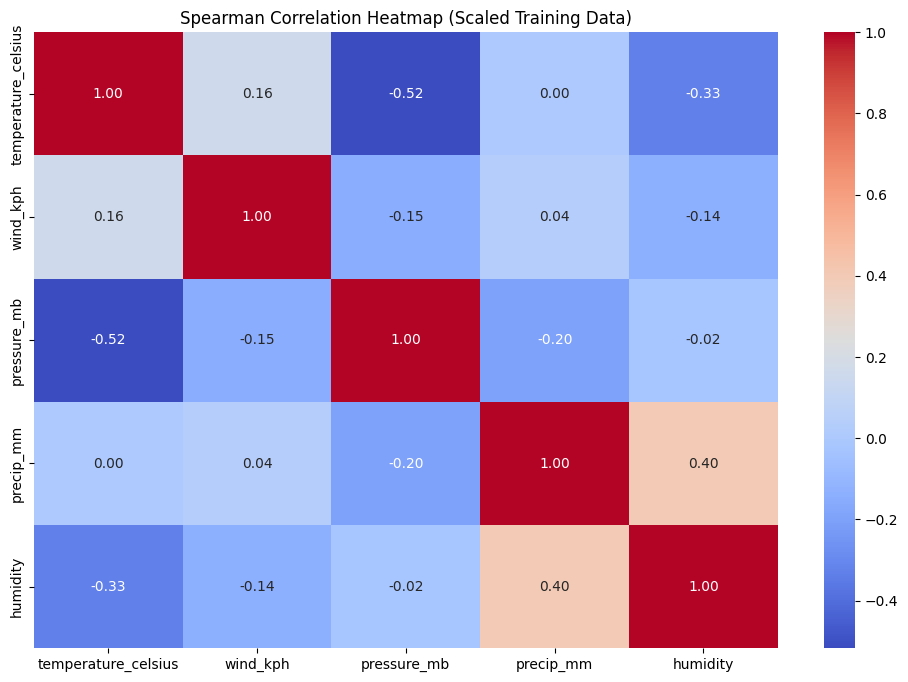

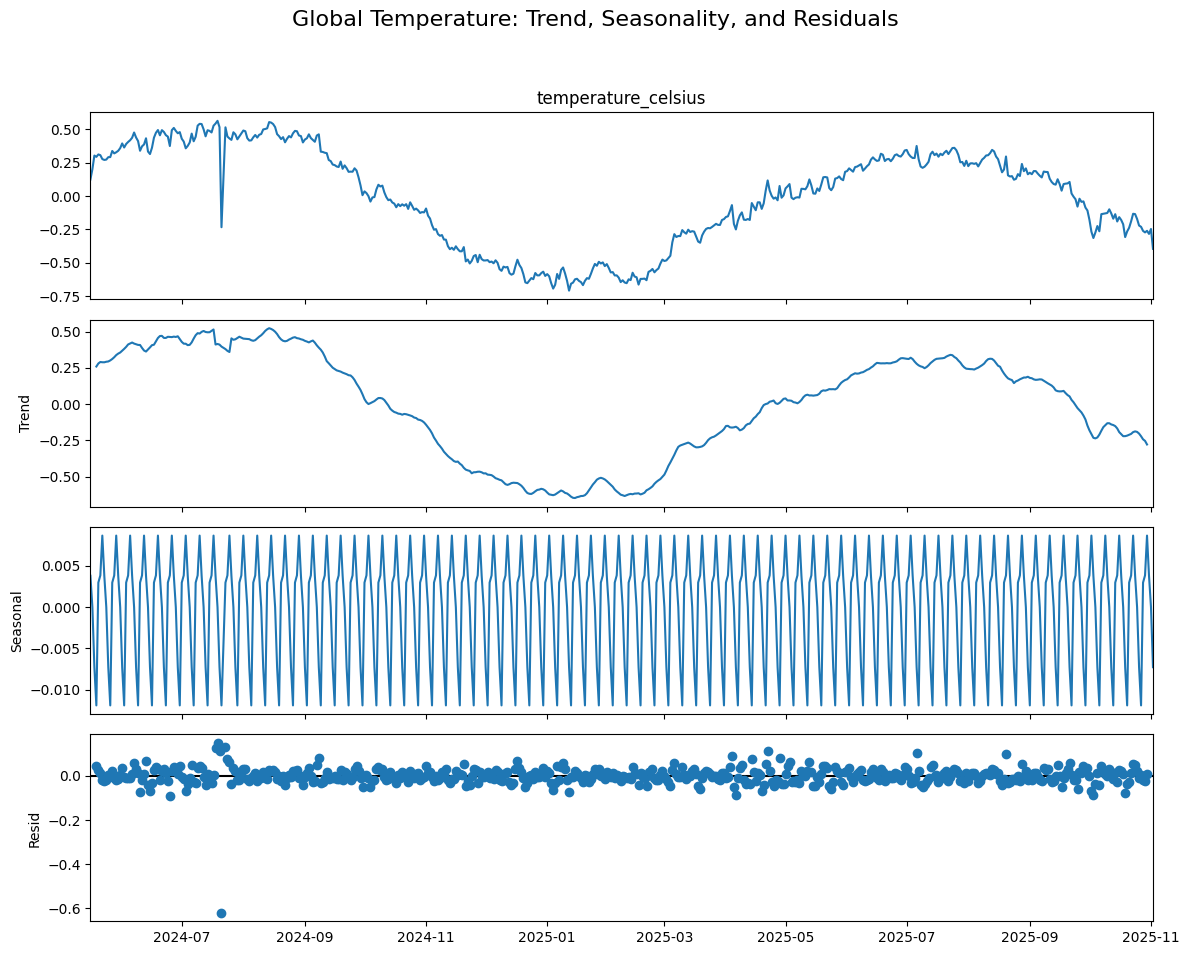

In [14]:

# Heatmap for Feature Relationships
plt.figure(figsize=(12, 8))
# spearman relation since weather relations are not linear
correlation_matrix = train_df[cols_to_scale].corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap (Scaled Training Data)")
plt.show()

# ensure column is datetime
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])

# set index and cast to DatetimeIndex (prevent pandas indexing error)
temp_series = train_df.set_index('last_updated')['temperature_celsius']
temp_series.index = pd.DatetimeIndex(temp_series.index)

# resample to daily mean and drop nans it could create
daily_temp = temp_series.resample('D').mean().dropna()

# Seasonal Decomposition
# typically weekly or yearly seasonality for weather
# stick with 7 for a short-term trend.


decomposition = seasonal_decompose(daily_temp, model='additive', period=7)

# plot
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Global Temperature: Trend, Seasonality, and Residuals', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

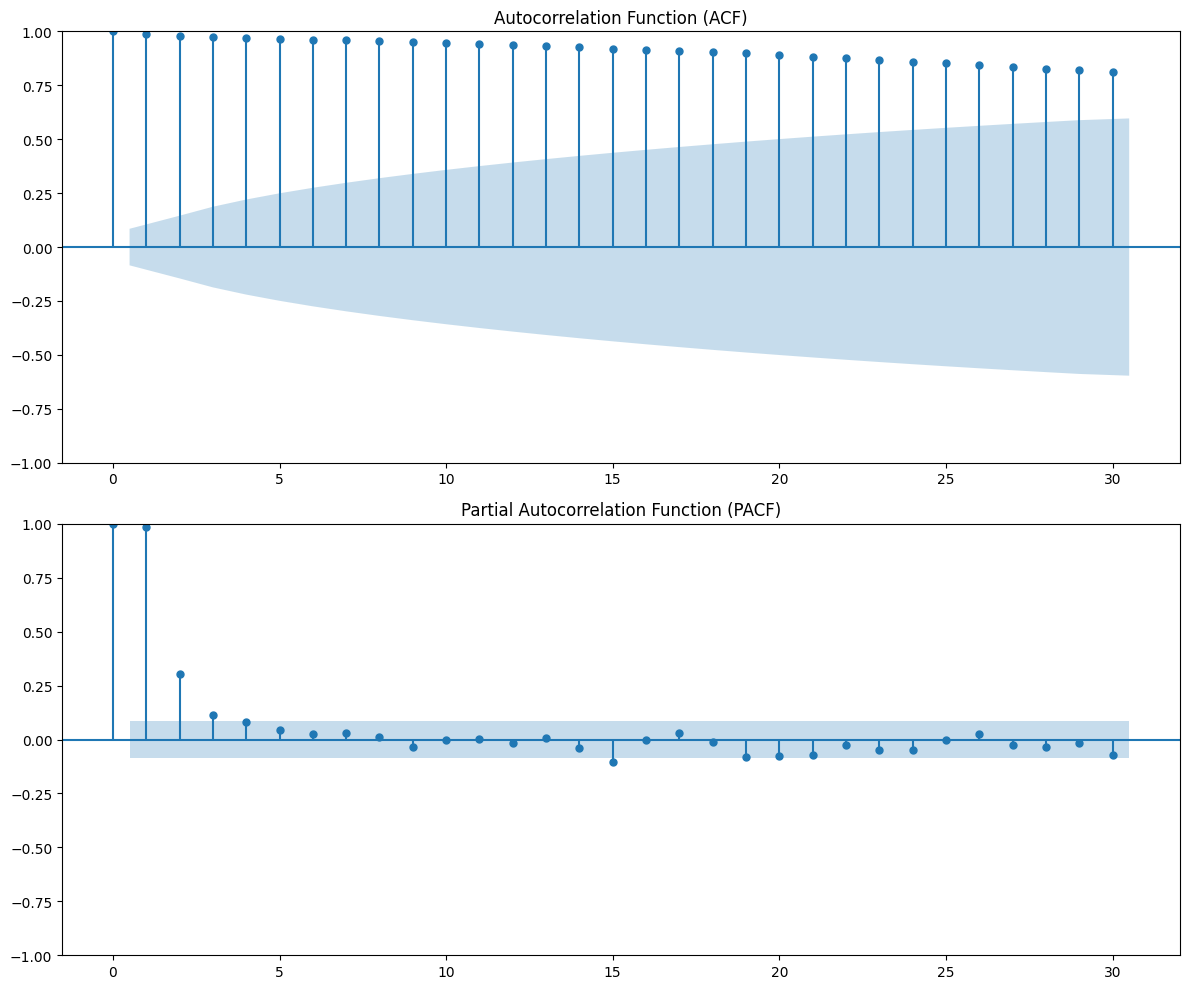

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF
plot_acf(daily_temp, lags=30, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# PACF
plot_pacf(daily_temp, lags=30, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

* Strong trend in the data
* todays weahter high correlated with yestearday, before, and so on
* Suggests Auto-Regressive (AR) process
* Almost all predictive power comes from the 1-2 days

### Visualization for temperature and precipitation
* boxplot of temp/precipitaion by continent or region

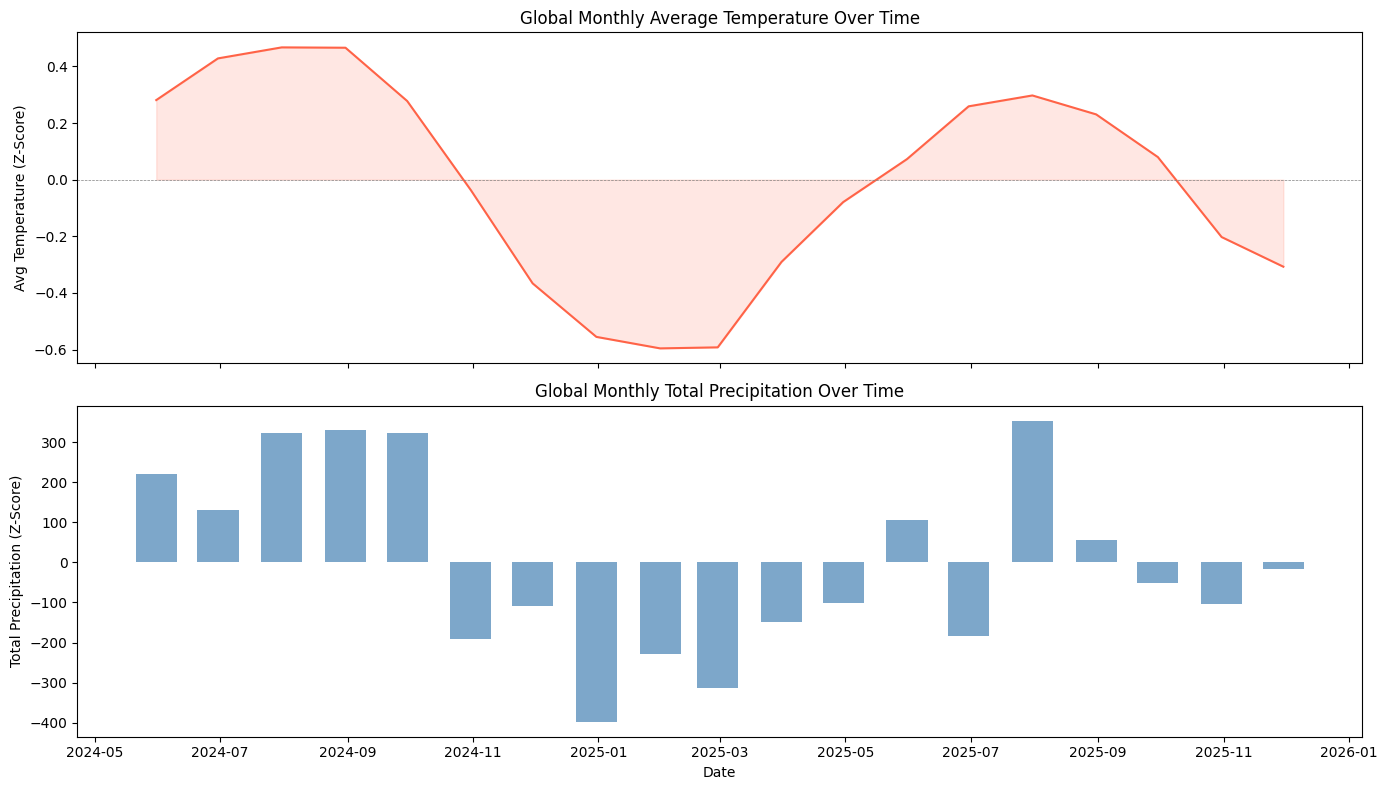

In [16]:
# temperature: monthly mean over time 
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])
monthly = train_df.set_index('last_updated').resample('ME').agg(
    temp_mean=('temperature_celsius', 'mean'),
    precip_sum=('precip_mm', 'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# temp trend
ax1.plot(monthly['last_updated'], monthly['temp_mean'], color='tomato', linewidth=1.5)
ax1.fill_between(monthly['last_updated'], monthly['temp_mean'], alpha=0.15, color='tomato')
ax1.set_ylabel('Avg Temperature (Z-Score)')
ax1.set_title('Global Monthly Average Temperature Over Time')
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# precip trend
ax2.bar(monthly['last_updated'], monthly['precip_sum'], color='steelblue',
        width=20, alpha=0.7)
ax2.set_ylabel('Total Precipitation (Z-Score)')
ax2.set_title('Global Monthly Total Precipitation Over Time')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

## Model Building

### Build a basic forecasting model and evaluate its performance using different metrics.
* Final planned model: XGBoost + LightGBM + LSTM
    * START with __XGBoost__

* target var: temperature_celsius? maybe not accurate for capturing TREND
    * use other target var or create
* target is scaled (z-scored). INVERSE it to better human interpretability 

In [17]:
warnings.filterwarnings('ignore')
# FEATURE ENGINNERING

def engineer_features(df_input):
    df_feat = df_input.copy()
    df_feat['last_updated'] = pd.to_datetime(df_feat['last_updated'])

    # cyclical time encodings (preserve periodicity) 
    df_feat['hour']       = df_feat['last_updated'].dt.hour
    df_feat['dayofyear']  = df_feat['last_updated'].dt.dayofyear
    df_feat['month']      = df_feat['last_updated'].dt.month

    df_feat['hour_sin']      = np.sin(2 * np.pi * df_feat['hour'] / 24)
    df_feat['hour_cos']      = np.cos(2 * np.pi * df_feat['hour'] / 24)
    df_feat['doy_sin']       = np.sin(2 * np.pi * df_feat['dayofyear'] / 365)
    df_feat['doy_cos']       = np.cos(2 * np.pi * df_feat['dayofyear'] / 365)
    df_feat['month_sin']     = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos']     = np.cos(2 * np.pi * df_feat['month'] / 12)

    # lag feats - per city to avoid leakage across locations
    df_feat = df_feat.sort_values(['location_name', 'last_updated'])
    for lag in [1, 2, 3, 6, 12, 24]:
        df_feat[f'temp_lag_{lag}'] = (
            df_feat.groupby('location_name')['temperature_celsius'].shift(lag)
        )

    # rolling statistics (per city) 
    for window in [6, 24]:
        df_feat[f'temp_roll_mean_{window}'] = (
            df_feat.groupby('location_name')['temperature_celsius']
            .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )
        df_feat[f'temp_roll_std_{window}'] = (
            df_feat.groupby('location_name')['temperature_celsius']
            .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
        )

    return df_feat


train_feat = engineer_features(train_df)
test_feat  = engineer_features(test_df)

# Drop rows where lag features are NaN (first observations per city)
train_feat = train_feat.dropna(subset=[c for c in train_feat.columns if 'lag' in c or 'roll' in c])
test_feat  = test_feat.dropna(subset=[c for c in test_feat.columns if 'lag' in c or 'roll' in c])

print(f"Train after feature engineering: {train_feat.shape}")
print(f"Test  after feature engineering: {test_feat.shape}")

Train after feature engineering: (98758, 60)
Test  after feature engineering: (21236, 60)


In [18]:
# FEATURES SET

FEATURE_COLS = [
    # meteorological features (already scaled)
    'humidity', 'pressure_mb', 'wind_kph', 'precip_mm',
    'cloud', 'uv_index', 'visibility_km',
    # spatial context
    'latitude', 'longitude',
    # cyclical time encodings
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
    # lag features
    'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_6', 'temp_lag_12', 'temp_lag_24',
    # rolling stats
    'temp_roll_mean_6', 'temp_roll_mean_24',
    'temp_roll_std_6',  'temp_roll_std_24',
]

TARGET = 'temperature_celsius'

X_train = train_feat[FEATURE_COLS]
y_train = train_feat[TARGET]

X_test  = test_feat[FEATURE_COLS]
y_test  = test_feat[TARGET]

print(f"Features: {len(FEATURE_COLS)} | X_train: {X_train.shape} | X_test: {X_test.shape}")

Features: 25 | X_train: (98758, 25) | X_test: (21236, 25)


In [19]:
# CROSS-VALIDATION (TimeSeriesSplit) 
# TimeSeriesSplit respects temporal ordering

tscv = TimeSeriesSplit(n_splits=5)

xgb_params = {
    'n_estimators':     500,
    'learning_rate':    0.05,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha':        0.1,    # L1
    'reg_lambda':       1.0,    # L2
    'tree_method':      'hist', # fast histogram method
    'random_state':     42,
    'n_jobs':           -1,
}

cv_maes, cv_rmses, cv_r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model_cv = xgb.XGBRegressor(**xgb_params)
    model_cv.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds_val = model_cv.predict(X_val)

    cv_maes.append(mean_absolute_error(y_val, preds_val))
    cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds_val)))
    cv_r2s.append(r2_score(y_val, preds_val))

    print(f"  Fold {fold+1} | MAE: {cv_maes[-1]:.4f} | RMSE: {cv_rmses[-1]:.4f} | R²: {cv_r2s[-1]:.4f}")

print(f"\nCV Summary (scaled units):")
print(f"  MAE  : {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}")
print(f"  RMSE : {np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}")
print(f"  R²   : {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

  Fold 1 | MAE: 0.1598 | RMSE: 0.2212 | R²: 0.9500
  Fold 2 | MAE: 0.1410 | RMSE: 0.1893 | R²: 0.9523
  Fold 3 | MAE: 0.1664 | RMSE: 0.2318 | R²: 0.9453
  Fold 4 | MAE: 0.1341 | RMSE: 0.1849 | R²: 0.9563
  Fold 5 | MAE: 0.1709 | RMSE: 0.2446 | R²: 0.9546

CV Summary (scaled units):
  MAE  : 0.1545 ± 0.0144
  RMSE : 0.2144 ± 0.0235
  R²   : 0.9517 ± 0.0038


In [20]:
# TRAINING

xgb_final = xgb.XGBRegressor(**xgb_params)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:1.41905
[100]	validation_0-rmse:0.27146
[200]	validation_0-rmse:0.26234
[300]	validation_0-rmse:0.25912
[400]	validation_0-rmse:0.25751
[499]	validation_0-rmse:0.25659


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [21]:
# EVALUATION on test set - invert scale for better read
# scaler was fit on ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity']
# temperature_celsius is index 0 - only invert its column

def inverse_temp(y_scaled):
    """Inverse the StandardScaler for temperature_celsius only (index 0)."""
    dummy = np.zeros((len(y_scaled), len(cols_to_scale)))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]

y_pred_scaled = xgb_final.predict(X_test)
y_pred_celsius = inverse_temp(y_pred_scaled)
y_true_celsius = inverse_temp(y_test.values)

mae  = mean_absolute_error(y_true_celsius, y_pred_celsius)
rmse = np.sqrt(mean_squared_error(y_true_celsius, y_pred_celsius))
r2   = r2_score(y_true_celsius, y_pred_celsius)
from sklearn.metrics import max_error
smape = np.mean(2 * np.abs(y_pred_celsius - y_true_celsius) /
                (np.abs(y_true_celsius) + np.abs(y_pred_celsius) + 1e-8)) * 100
max_err = max_error(y_true_celsius, y_pred_celsius)

print("──────── XGBoost Final Model — Test Set Performance ────────────")
print(f"  MAE      : {mae:.3f} °C")
print(f"  RMSE     : {rmse:.3f} °C")
print(f"  R²       : {r2:.4f}")
print(f"  sMAPE    : {smape:.2f}%")
print(f"  Max Error: {max_err:.3f} °C")

──────── XGBoost Final Model — Test Set Performance ────────────
  MAE      : 1.541 °C
  RMSE     : 2.271 °C
  R²       : 0.9603
  sMAPE    : 26.45%
  Max Error: 17.752 °C


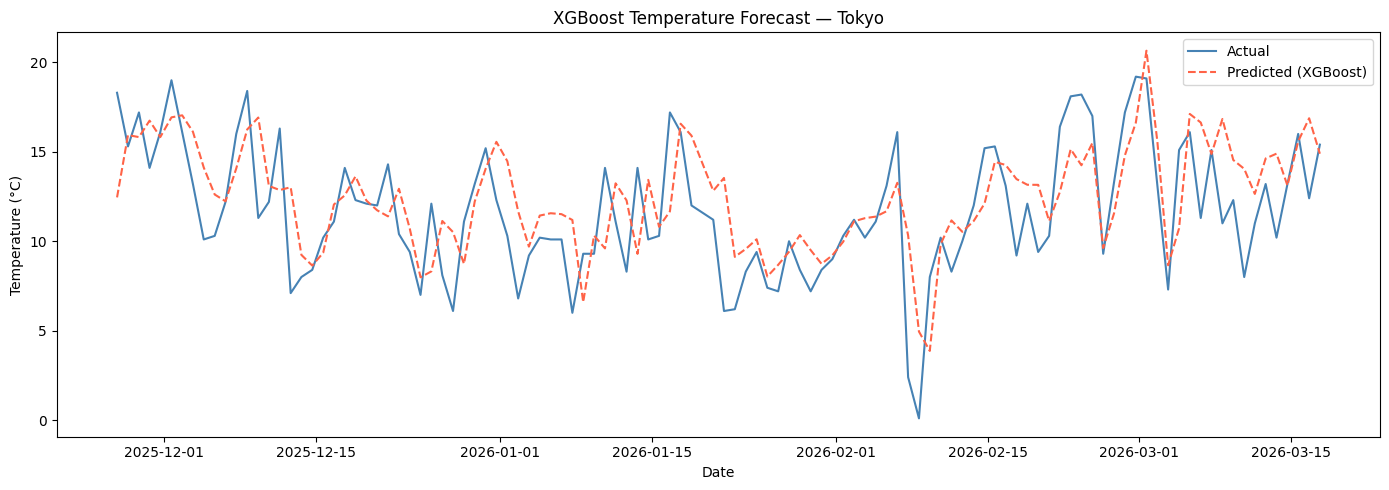

In [22]:
# VISUALIZE PREDICTIONS 
# plot single city to show temporal fit

city = 'Tokyo'   # CHANGE CITY
city_mask_test = test_feat['location_name'] == city

if city_mask_test.sum() > 0:
    city_test = test_feat[city_mask_test].copy()
    city_preds = xgb_final.predict(city_test[FEATURE_COLS])

    city_true_c = inverse_temp(city_test[TARGET].values)
    city_pred_c = inverse_temp(city_preds)
    dates = city_test['last_updated']

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, city_true_c, label='Actual', color='steelblue', linewidth=1.5)
    ax.plot(dates, city_pred_c, label='Predicted (XGBoost)', color='tomato',
            linewidth=1.5, linestyle='--')
    ax.set_title(f'XGBoost Temperature Forecast — {city}')
    ax.set_ylabel('Temperature (°C)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"'{city}' not found in test set. Available sample cities:")
    print(test_feat['location_name'].unique()[:10])

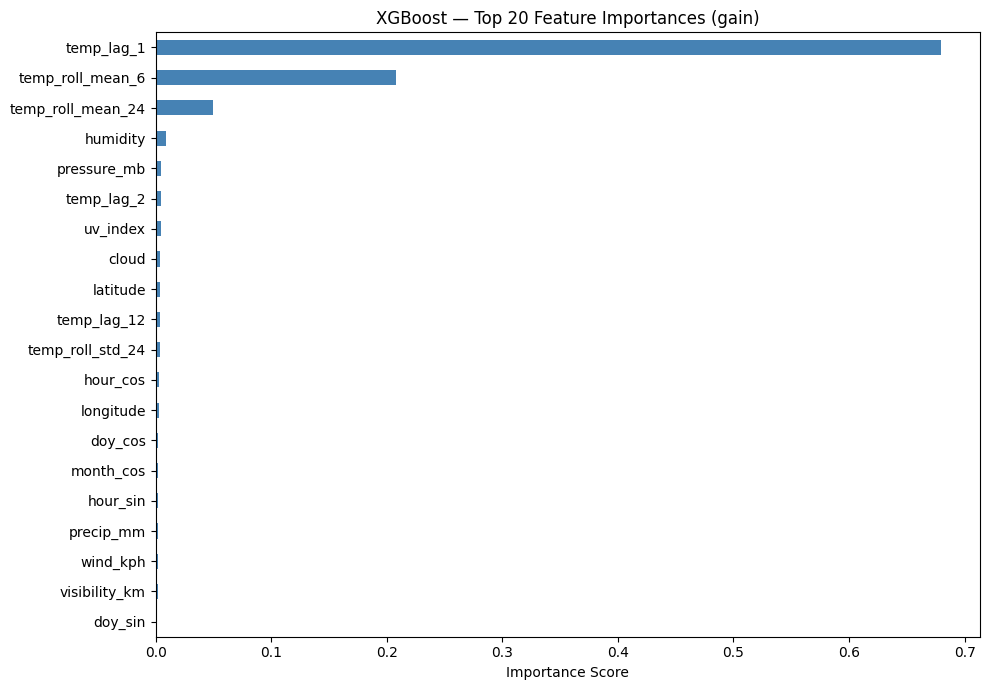


Top 10 features:
temp_lag_1           0.679374
temp_roll_mean_6     0.207862
temp_roll_mean_24    0.049372
humidity             0.008567
pressure_mb          0.004976
temp_lag_2           0.004758
uv_index             0.004310
cloud                0.003906
latitude             0.003774
temp_lag_12          0.003758


In [23]:
# FEATURE IMPORTANCE PLOT

importances = pd.Series(xgb_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('XGBoost — Top 20 Feature Importances (gain)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string())

### Use lastupdated feature for the time series analysis.

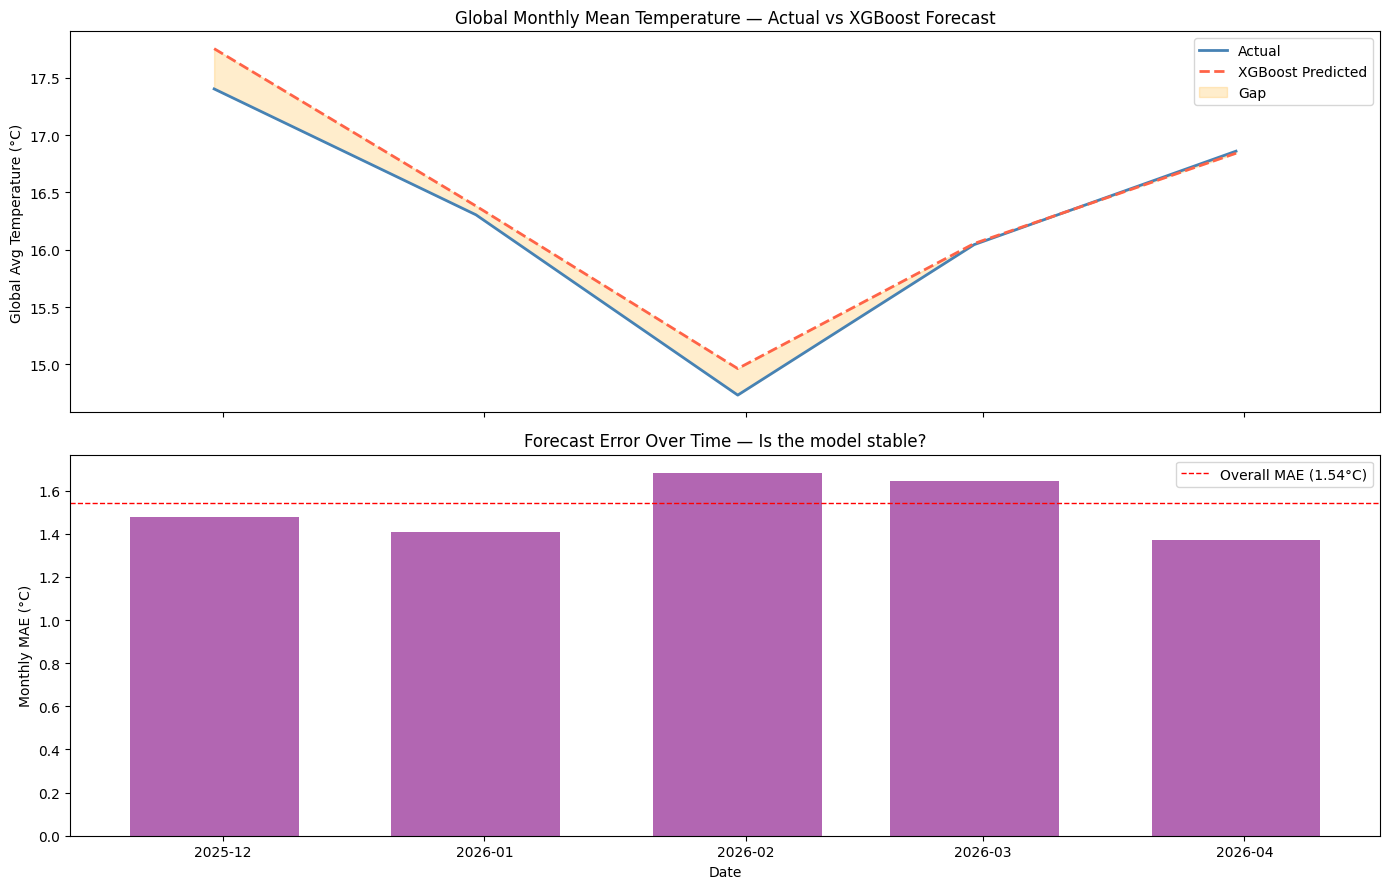

In [24]:
ts_df = test_feat[['last_updated', 'location_name', 'latitude', 'longitude']].copy()
ts_df['last_updated'] = pd.to_datetime(ts_df['last_updated'])
ts_df['y_true']       = y_true_celsius
ts_df['y_pred']       = y_pred_celsius
ts_df['residual']     = ts_df['y_true'] - ts_df['y_pred']
ts_df['abs_error']    = ts_df['residual'].abs()

# GLOBAL TEMP TREND PLOT 
monthly_ts = ts_df.set_index('last_updated').resample('ME').agg(
    true_mean  = ('y_true', 'mean'),
    pred_mean  = ('y_pred', 'mean'),
    mae_monthly= ('abs_error', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# actual vs predicted global mean temperature
axes[0].plot(monthly_ts['last_updated'], monthly_ts['true_mean'],
             color='steelblue', linewidth=2, label='Actual')
axes[0].plot(monthly_ts['last_updated'], monthly_ts['pred_mean'],
             color='tomato', linewidth=2, linestyle='--', label='XGBoost Predicted')
axes[0].fill_between(monthly_ts['last_updated'],
                     monthly_ts['true_mean'], monthly_ts['pred_mean'],
                     alpha=0.2, color='orange', label='Gap')
axes[0].set_ylabel('Global Avg Temperature (°C)')
axes[0].set_title('Global Monthly Mean Temperature — Actual vs XGBoost Forecast')
axes[0].legend()

# Panel 2: Monthly MAE over time (model reliability drift check)
axes[1].bar(monthly_ts['last_updated'], monthly_ts['mae_monthly'],
            color='purple', alpha=0.6, width=20)
axes[1].axhline(mae, color='red', linestyle='--', linewidth=1, label=f'Overall MAE ({mae:.2f}°C)')
axes[1].set_ylabel('Monthly MAE (°C)')
axes[1].set_title('Forecast Error Over Time — Is the model stable?')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

### LIGHTGBM building & Ensemble with XGBOOST

In [25]:
# LIGHTGBM — CROSS-VALIDATION


import lightgbm as lgb
from scipy.optimize import minimize_scalar

lgb_params = {
    'n_estimators':      1000,  # high ceiling — early stopping finds optimum
    'learning_rate':     0.05,  # same as XGB for fair comparison
    'num_leaves':        63,    # PRIMARY LightGBM param: ~2^6-1, depth-6 equivalent
    'max_depth':         -1,    # unconstrained; num_leaves governs complexity
    'min_child_samples': 20,    # min obs per leaf, LightGBM equiv of min_child_weight
    'feature_fraction':  0.8,   # col subsampling per tree (= colsample_bytree)
    'bagging_fraction':  0.8,   # row subsampling (= subsample)
    'bagging_freq':      1,     # enable bagging every round
    'reg_alpha':         0.1,   # L1 — matches XGB
    'reg_lambda':        1.0,   # L2 — matches XGB
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,    # suppress C++ output
}

lgb_cv_maes, lgb_cv_rmses, lgb_cv_r2s = [], [], []
lgb_best_iters = []

print("─────────── LightGBM 5-Fold TimeSeriesSplit CV ─────────────────")
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    _lgb_cv = lgb.LGBMRegressor(**lgb_params)
    _lgb_cv.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=9999),   # silent during CV
        ]
    )

    lgb_best_iters.append(_lgb_cv.best_iteration_)
    preds_val = _lgb_cv.predict(X_val, num_iteration=_lgb_cv.best_iteration_)

    lgb_cv_maes.append(mean_absolute_error(y_val, preds_val))
    lgb_cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds_val)))
    lgb_cv_r2s.append(r2_score(y_val, preds_val))
    print(f"  Fold {fold+1} | MAE: {lgb_cv_maes[-1]:.4f} | RMSE: {lgb_cv_rmses[-1]:.4f} "
          f"| R²: {lgb_cv_r2s[-1]:.4f} | Best iter: {lgb_best_iters[-1]}")

# derive optimal estimators: mean best_iteration across folds + 10% buffer
optimal_n_estimators = max(100, int(np.mean(lgb_best_iters) * 1.1))

print(f"\nCV Summary (scaled units):")
print(f"  MAE  : {np.mean(lgb_cv_maes):.4f} ± {np.std(lgb_cv_maes):.4f}")
print(f"  RMSE : {np.mean(lgb_cv_rmses):.4f} ± {np.std(lgb_cv_rmses):.4f}")
print(f"  R²   : {np.mean(lgb_cv_r2s):.4f} ± {np.std(lgb_cv_r2s):.4f}")
print(f"\n  CV-derived optimal n_estimators: {optimal_n_estimators}")

─────────── LightGBM 5-Fold TimeSeriesSplit CV ─────────────────
  Fold 1 | MAE: 0.1577 | RMSE: 0.2186 | R²: 0.9512 | Best iter: 226
  Fold 2 | MAE: 0.1418 | RMSE: 0.1913 | R²: 0.9513 | Best iter: 238
  Fold 3 | MAE: 0.1621 | RMSE: 0.2251 | R²: 0.9484 | Best iter: 127
  Fold 4 | MAE: 0.1303 | RMSE: 0.1810 | R²: 0.9581 | Best iter: 236
  Fold 5 | MAE: 0.1650 | RMSE: 0.2388 | R²: 0.9567 | Best iter: 964

CV Summary (scaled units):
  MAE  : 0.1514 ± 0.0132
  RMSE : 0.2109 ± 0.0215
  R²   : 0.9532 ± 0.0037

  CV-derived optimal n_estimators: 394


In [26]:
# LIGHTGBM — TRAIN  MODEL 

lgb_final_params = {**lgb_params, 'n_estimators': optimal_n_estimators}

lgb_final = lgb.LGBMRegressor(**lgb_final_params)
lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],   # monitor train loss for convergence check
    callbacks=[lgb.log_evaluation(period=100)] # show training progress every 100 rounds.
)

print(f"\nLightGBM trained with {optimal_n_estimators} estimators.")

[100]	training's l2: 0.0382749
[200]	training's l2: 0.0309102
[300]	training's l2: 0.0269889

LightGBM trained with 394 estimators.


In [27]:
# LIGHTGBM — EVALUATE ON TEST SET 

y_pred_lgb_scaled  = lgb_final.predict(X_test)
y_pred_lgb_celsius = inverse_temp(y_pred_lgb_scaled)

lgb_mae   = mean_absolute_error(y_true_celsius, y_pred_lgb_celsius)
lgb_rmse  = np.sqrt(mean_squared_error(y_true_celsius, y_pred_lgb_celsius))
lgb_r2    = r2_score(y_true_celsius, y_pred_lgb_celsius)
lgb_smape = np.mean(2 * np.abs(y_pred_lgb_celsius - y_true_celsius) /
                    (np.abs(y_true_celsius) + np.abs(y_pred_lgb_celsius) + 1e-8)) * 100
lgb_max_err = max_error(y_true_celsius, y_pred_lgb_celsius)

print("── LightGBM Final Model — Test Set Performance ─────────────────")
print(f"  MAE      : {lgb_mae:.3f} °C")
print(f"  RMSE     : {lgb_rmse:.3f} °C")
print(f"  R²       : {lgb_r2:.4f}")
print(f"  sMAPE    : {lgb_smape:.2f}%")
print(f"  Max Error: {lgb_max_err:.3f} °C")

── LightGBM Final Model — Test Set Performance ─────────────────
  MAE      : 1.535 °C
  RMSE     : 2.246 °C
  R²       : 0.9611
  sMAPE    : 26.59%
  Max Error: 17.714 °C


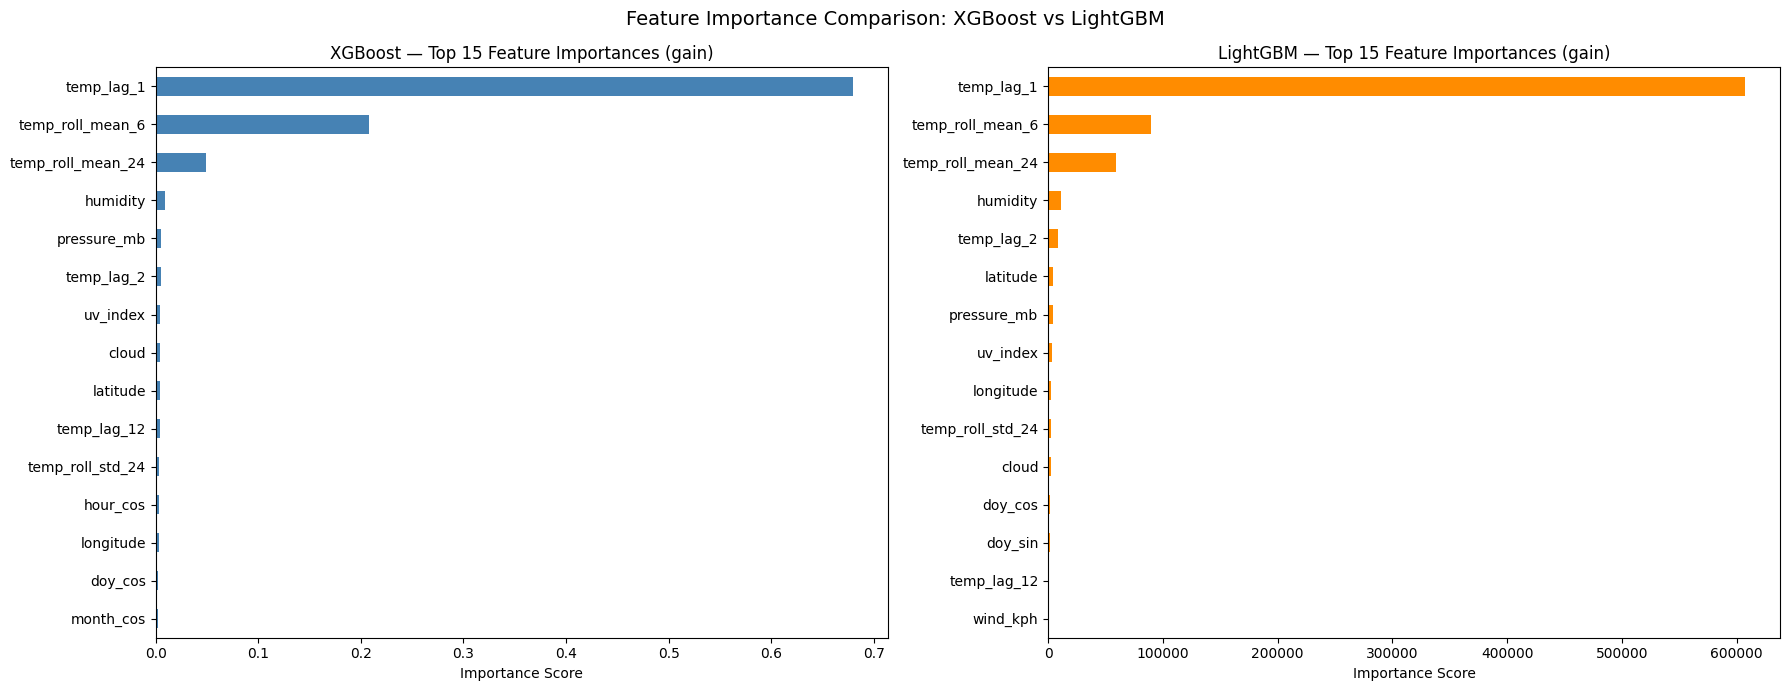

In [28]:
# LIGHTGBM — FEATURE IMPORTANCE (gain, matches XGBoost's metric) 

lgb_importances = pd.Series(
    lgb_final.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# XGBoost importances (already computed)
xgb_importances = pd.Series(
    xgb_final.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

xgb_importances.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('XGBoost — Top 15 Feature Importances (gain)')
axes[0].set_xlabel('Importance Score')

lgb_importances.head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('LightGBM — Top 15 Feature Importances (gain)')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison: XGBoost vs LightGBM', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# ENSEMBLE — OPTIMAL WEIGHTED AVERAGE
# joint OOF loop on the same TimeSeriesSplit folds to ensure both models see identical training/validation splits. OOF predictions are used to find the single optimal weight w via 1D bounded minimization (minimize_scalar), where ensemble = w*XGB + (1-w)*LGB.

print("────────── Collecting OOF predictions (joint CV loop) ──────────")

xgb_oof = np.zeros(len(X_train))
lgb_oof = np.zeros(len(X_train))

# use same tscv; models use their already-tuned param dicts
_lgb_oof_params = {**lgb_params, 'n_estimators': optimal_n_estimators}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # XGBoost fold
    _xgb = xgb.XGBRegressor(**xgb_params)
    _xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_oof[val_idx] = _xgb.predict(X_val)

    # LightGBM fold
    _lgb = lgb.LGBMRegressor(**_lgb_oof_params)
    _lgb.fit(X_tr, y_tr)
    lgb_oof[val_idx] = _lgb.predict(X_val)

    print(f"  Fold {fold+1} done.")

print("\nOOF predictions collected.")

────────── Collecting OOF predictions (joint CV loop) ──────────
  Fold 1 done.
  Fold 2 done.
  Fold 3 done.
  Fold 4 done.
  Fold 5 done.

OOF predictions collected.


Optimal ensemble weights (OOF-derived):
  XGBoost  : 0.3652  (36.5%)
  LightGBM : 0.6348  (63.5%)

OOF MAE at optimal weight : 0.2581 (scaled)


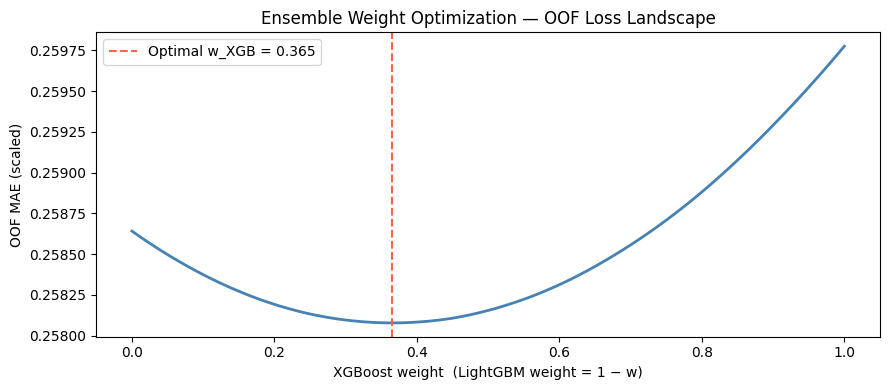

In [30]:
# OPTIMIZE ENSEMBLE WEIGHT ON OOF 
# 1D problem: find w* = argmin MAE(y_train, w*XGB_OOF + (1-w)*LGB_OOF)
# bounded to [0, 1] so weights stay convex (no negative weights).

def oof_mae(w):
    """Ensemble loss as a function of XGBoost weight w."""
    ensemble_pred = w * xgb_oof + (1 - w) * lgb_oof
    return mean_absolute_error(y_train.values, ensemble_pred)

result = minimize_scalar(oof_mae, bounds=(0.0, 1.0), method='bounded',
                         options={'xatol': 1e-6})

w_xgb = result.x
w_lgb = 1.0 - w_xgb

print(f"Optimal ensemble weights (OOF-derived):")
print(f"  XGBoost  : {w_xgb:.4f}  ({w_xgb*100:.1f}%)")
print(f"  LightGBM : {w_lgb:.4f}  ({w_lgb*100:.1f}%)")
print(f"\nOOF MAE at optimal weight : {result.fun:.4f} (scaled)")

# scan the loss landscape
w_range = np.linspace(0, 1, 101)
oof_losses = [oof_mae(w) for w in w_range]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w_range, oof_losses, color='steelblue', linewidth=2)
ax.axvline(w_xgb, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Optimal w_XGB = {w_xgb:.3f}')
ax.set_xlabel('XGBoost weight  (LightGBM weight = 1 − w)')
ax.set_ylabel('OOF MAE (scaled)')
ax.set_title('Ensemble Weight Optimization — OOF Loss Landscape')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
#  ENSEMBLE — GENERATE TEST PREDICTIONS & EVALUATE 

y_ensemble_scaled  = w_xgb * y_pred_scaled + w_lgb * y_pred_lgb_scaled
y_ensemble_celsius = inverse_temp(y_ensemble_scaled)

ens_mae     = mean_absolute_error(y_true_celsius, y_ensemble_celsius)
ens_rmse    = np.sqrt(mean_squared_error(y_true_celsius, y_ensemble_celsius))
ens_r2      = r2_score(y_true_celsius, y_ensemble_celsius)
ens_smape   = np.mean(2 * np.abs(y_ensemble_celsius - y_true_celsius) /
                      (np.abs(y_true_celsius) + np.abs(y_ensemble_celsius) + 1e-8)) * 100
ens_max_err = max_error(y_true_celsius, y_ensemble_celsius)

print("────────── Ensemble Final — Test Set Performance ───────────────")
print(f"  MAE      : {ens_mae:.3f} °C")
print(f"  RMSE     : {ens_rmse:.3f} °C")
print(f"  R²       : {ens_r2:.4f}")
print(f"  sMAPE    : {ens_smape:.2f}%")
print(f"  Max Error: {ens_max_err:.3f} °C")

────────── Ensemble Final — Test Set Performance ───────────────
  MAE      : 1.530 °C
  RMSE     : 2.244 °C
  R²       : 0.9612
  sMAPE    : 26.44%
  Max Error: 17.728 °C



─────────────── Full Model Comparison ──────────────────────────
                         MAE (°C)  RMSE (°C)      R²  sMAPE (%)  Max Err
Model                                                                   
XGBoost                    1.5414     2.2707  0.9603    26.4464  17.7515
LightGBM                   1.5353     2.2464  0.9611    26.5912  17.7139
Ensemble\n(w=0.37/0.63)    1.5298     2.2441  0.9612    26.4385  17.7276


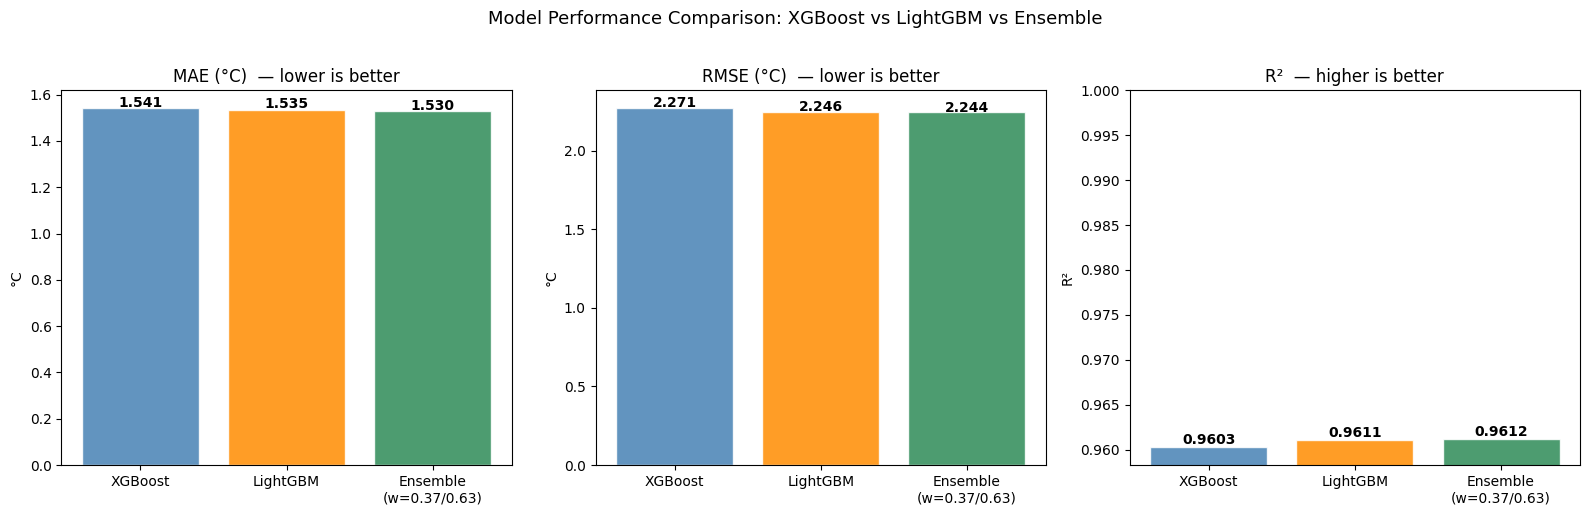

In [32]:
#  MODEL COMPARISON TABLE & CHART 

comparison_df = pd.DataFrame({
    'Model':     ['XGBoost', 'LightGBM', f'Ensemble\n(w={w_xgb:.2f}/{w_lgb:.2f})'],
    'MAE (°C)':  [mae,       lgb_mae,    ens_mae],
    'RMSE (°C)': [rmse,      lgb_rmse,   ens_rmse],
    'R²':        [r2,        lgb_r2,     ens_r2],
    'sMAPE (%)': [smape,     lgb_smape,  ens_smape],
    'Max Err':   [max_err,   lgb_max_err,ens_max_err],
})
comparison_df = comparison_df.set_index('Model')
print("\n─────────────── Full Model Comparison ──────────────────────────")
print(comparison_df.round(4).to_string())

#  Visual comparison 
metrics_plot = comparison_df[['MAE (°C)', 'RMSE (°C)']].copy()
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE
axes[0].bar(metrics_plot.index, metrics_plot['MAE (°C)'],
            color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('MAE (°C)  — lower is better')
axes[0].set_ylabel('°C')
for i, v in enumerate(metrics_plot['MAE (°C)']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# RMSE
axes[1].bar(metrics_plot.index, metrics_plot['RMSE (°C)'],
            color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('RMSE (°C)  — lower is better')
axes[1].set_ylabel('°C')
for i, v in enumerate(metrics_plot['RMSE (°C)']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# R²
axes[2].bar(comparison_df.index, comparison_df['R²'],
            color=colors, alpha=0.85, edgecolor='white')
axes[2].set_title('R²  — higher is better')
axes[2].set_ylabel('R²')
axes[2].set_ylim(min(comparison_df['R²']) - 0.002, 1.0)
for i, v in enumerate(comparison_df['R²']):
    axes[2].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Model Performance Comparison: XGBoost vs LightGBM vs Ensemble',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

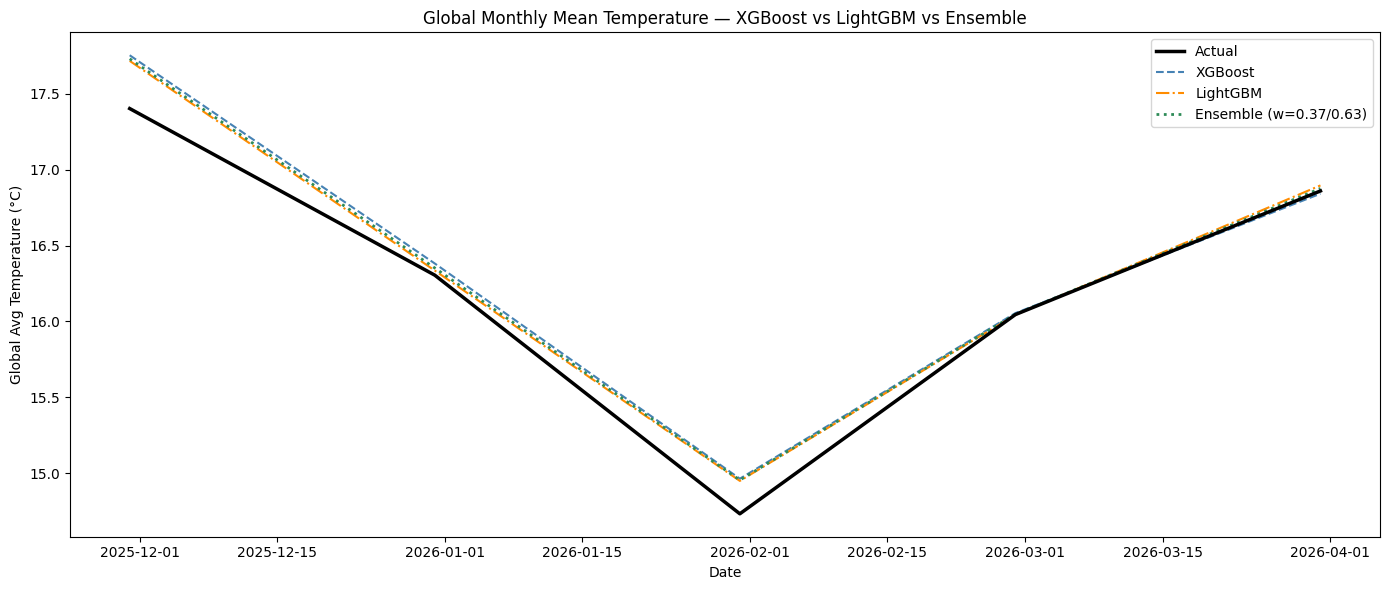

In [33]:
#  TEMPORAL COMPARISON: All 3 models on global monthly mean 

ts_ens_df = test_feat[['last_updated', 'location_name']].copy()
ts_ens_df['last_updated'] = pd.to_datetime(ts_ens_df['last_updated'])
ts_ens_df['y_true']      = y_true_celsius
ts_ens_df['xgb_pred']    = y_pred_celsius
ts_ens_df['lgb_pred']    = y_pred_lgb_celsius
ts_ens_df['ens_pred']    = y_ensemble_celsius

monthly_cmp = ts_ens_df.set_index('last_updated').resample('ME').agg(
    true_mean = ('y_true',   'mean'),
    xgb_mean  = ('xgb_pred', 'mean'),
    lgb_mean  = ('lgb_pred', 'mean'),
    ens_mean  = ('ens_pred', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_cmp['last_updated'], monthly_cmp['true_mean'],
        color='black', linewidth=2.5, label='Actual', zorder=5)
ax.plot(monthly_cmp['last_updated'], monthly_cmp['xgb_mean'],
        color='steelblue', linewidth=1.5, linestyle='--', label='XGBoost')
ax.plot(monthly_cmp['last_updated'], monthly_cmp['lgb_mean'],
        color='darkorange', linewidth=1.5, linestyle='-.', label='LightGBM')
ax.plot(monthly_cmp['last_updated'], monthly_cmp['ens_mean'],
        color='seagreen', linewidth=2, linestyle=':', label=f'Ensemble (w={w_xgb:.2f}/{w_lgb:.2f})')

ax.set_ylabel('Global Avg Temperature (°C)')
ax.set_xlabel('Date')
ax.set_title('Global Monthly Mean Temperature — XGBoost vs LightGBM vs Ensemble')
ax.legend()
plt.tight_layout()
plt.show()

## Unique Analyses

In [ ]:
# ADVANCED ASSESSMENT — UNIQUE ANALYSES
#  use `df` (domain-clipped, original scale, not z-scored).
# No continent column in dataset — map from country name.

COUNTRY_TO_CONTINENT = {
    # Africa
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi','Cameroon',
    'Cape Verde','Central African Republic','Chad','Comoros','Congo',
    'Democratic Republic of the Congo','Djibouti','Egypt','Equatorial Guinea',
    'Eritrea','Ethiopia','Gabon','Gambia','Ghana','Guinea','Guinea-Bissau',
    'Ivory Coast','Kenya','Lesotho','Liberia','Libya','Madagascar','Malawi',
    'Mali','Mauritania','Mauritius','Morocco','Mozambique','Namibia','Niger',
    'Nigeria','Rwanda','Sao Tome and Principe','Senegal','Sierra Leone','Somalia',
    'South Africa','South Sudan','Sudan','Swaziland','Tanzania','Togo','Tunisia',
    'Uganda','Zambia','Zimbabwe',
}
CONTINENT_MAP = {}
for c in COUNTRY_TO_CONTINENT:
    CONTINENT_MAP[c] = 'Africa'

for c in ['Afghanistan','Armenia','Azerbaijan','Bahrain','Bangladesh','Bhutan',
          'Brunei','Cambodia','China','Georgia','India','Indonesia','Iran','Iraq',
          'Israel','Japan','Jordan','Kazakhstan','Kuwait','Kyrgyzstan','Laos',
          'Lebanon','Malaysia','Maldives','Mongolia','Myanmar','Nepal','North Korea',
          'Oman','Pakistan','Palestine','Philippines','Qatar','Saudi Arabia',
          'Singapore','South Korea','Sri Lanka','Syria','Taiwan','Tajikistan',
          'Thailand','Timor-Leste','Turkey','Turkmenistan','United Arab Emirates',
          'Uzbekistan','Vietnam','Yemen']:
    CONTINENT_MAP[c] = 'Asia'

for c in ['Albania','Andorra','Austria','Belarus','Belgium','Bosnia and Herzegovina',
          'Bulgaria','Croatia','Cyprus','Czech Republic','Denmark','Estonia',
          'Finland','France','Germany','Greece','Hungary','Iceland','Ireland',
          'Italy','Kosovo','Latvia','Liechtenstein','Lithuania','Luxembourg',
          'Malta','Moldova','Monaco','Montenegro','Netherlands','North Macedonia',
          'Norway','Poland','Portugal','Romania','Russia','San Marino','Serbia',
          'Slovakia','Slovenia','Spain','Sweden','Switzerland','Ukraine',
          'United Kingdom']:
    CONTINENT_MAP[c] = 'Europe'

for c in ['Antigua and Barbuda','Bahamas','Barbados','Belize','Canada','Costa Rica',
          'Cuba','Dominica','Dominican Republic','El Salvador','Grenada','Guatemala',
          'Haiti','Honduras','Jamaica','Mexico','Nicaragua','Panama',
          'Saint Kitts and Nevis','Saint Lucia','Saint Vincent and the Grenadines',
          'Trinidad and Tobago','United States']:
    CONTINENT_MAP[c] = 'North America'

for c in ['Argentina','Bolivia','Brazil','Chile','Colombia','Ecuador','Guyana',
          'Paraguay','Peru','Suriname','Uruguay','Venezuela']:
    CONTINENT_MAP[c] = 'South America'

for c in ['Australia','Fiji','Kiribati','Marshall Islands','Micronesia','Nauru',
          'New Zealand','Palau','Papua New Guinea','Samoa','Solomon Islands',
          'Tonga','Tuvalu','Vanuatu']:
    CONTINENT_MAP[c] = 'Oceania'

# copy df with continent column (original scale, all 130k rows)
analysis_df = df.copy()

# contry name regularization
# The dataset stores country names in multiple languages  

COUNTRY_NORMALIZE = {
    # Russian
    'Турция': 'Turkey', 'Россия': 'Russia', 'Германия': 'Germany',
    'Франция': 'France', 'Испания': 'Spain', 'Италия': 'Italy',
    'Китай': 'China', 'Япония': 'Japan', 'Индия': 'India',
    'Монголия': 'Mongolia', 'Бразилия': 'Brazil', 'Аргентина': 'Argentina',
    'Мексика': 'Mexico', 'Польша': 'Poland', 'Румыния': 'Romania',
    'Украина': 'Ukraine', 'Казахстан': 'Kazakhstan', 'Швеция': 'Sweden',
    'Норвегия': 'Norway', 'Финляндия': 'Finland', 'Дания': 'Denmark',
    'Нидерланды': 'Netherlands', 'Венгрия': 'Hungary', 'Беларусь': 'Belarus',
    'Сербия': 'Serbia', 'Хорватия': 'Croatia', 'Болгария': 'Bulgaria',
    'Словакия': 'Slovakia', 'Литва': 'Lithuania', 'Латвия': 'Latvia',
    'Эстония': 'Estonia', 'Грузия': 'Georgia', 'Армения': 'Armenia',
    'Азербайджан': 'Azerbaijan', 'Узбекистан': 'Uzbekistan',
    'Туркменистан': 'Turkmenistan', 'Таджикистан': 'Tajikistan',
    'Кыргызстан': 'Kyrgyzstan', 'Афганистан': 'Afghanistan',
    # French
    'Inde': 'India', 'Chine': 'China', 'Japon': 'Japan',
    'Allemagne': 'Germany', 'Italie': 'Italy', 'Espagne': 'Spain',
    'Maroc': 'Morocco', 'Marrocos': 'Morocco', 'Mexique': 'Mexico',
    'Brésil': 'Brasil', 'Algérie': 'Algeria', 'Tunisie': 'Tunisia',
    'Turkménistan': 'Turkmenistan', 'Azerbaïdjan': 'Azerbaijan',
    'Royaume-Uni': 'United Kingdom', 'États-Unis': 'United States',
    # German
    'Saudi Arabien': 'Saudi Arabia', 'Vereinigte Staaten': 'United States',
    'Vereinigtes Königreich': 'United Kingdom', 'Türkei': 'Turkey',
    'Marokko': 'Morocco', 'Ägypten': 'Egypt', 'Irak': 'Iraq',
    'Kenia': 'Kenya', 'Äthiopien': 'Ethiopia', 'Algerien': 'Algeria',
    'Schweden': 'Sweden', 'Norwegen': 'Norway', 'Österreich': 'Austria',
    'Ungarn': 'Hungary', 'Rumänien': 'Romania', 'Tunesien': 'Tunisia',
    # Other  variants
    'United States of America': 'United States',
    'USA': 'United States',
    'UK': 'United Kingdom',
    'Türkiye': 'Turkey',          
    'Czechia': 'Czech Republic',
    'Ivory Coast': "Ivory Coast",
    "Cote d'Ivoire": 'Ivory Coast',
    'Congo (Brazzaville)': 'Congo',
    'Congo (Kinshasa)': 'Democratic Republic of the Congo',
    'South Korea': 'South Korea',
    'Korea, South': 'South Korea',
    'Korea, North': 'North Korea',
}

def normalize_country(name):
    return COUNTRY_NORMALIZE.get(name, name)


analysis_df['country'] = analysis_df['country'].map(normalize_country)
analysis_df['continent'] = analysis_df['country'].map(CONTINENT_MAP).fillna('Other')

normalized_unknown = analysis_df[analysis_df['continent'] == 'Other']['country'].unique()
print(f"Countries still unmapped to a continent ({len(normalized_unknown)}):")
print(sorted(normalized_unknown))

analysis_df['last_updated'] = pd.to_datetime(analysis_df['last_updated'])
analysis_df['continent'] = analysis_df['country'].map(CONTINENT_MAP).fillna('Other')
analysis_df['month'] = analysis_df['last_updated'].dt.month

print(f"Analysis base: {analysis_df.shape}")
print("-----------")
print("Continent distribution:")
print(analysis_df['continent'].value_counts().to_string())

Countries still unmapped to a continent (21):
['Brunei Darussalam', 'Bélgica', 'Democratic Republic of Congo', 'Estonie', 'Fiji Islands', 'Jemen', 'Komoren', 'Kyrghyzstan', "Lao People's Democratic Republic", 'Letonia', 'Macedonia', 'Malásia', 'Polônia', 'Saint-Vincent-et-les-Grenadines', 'Seychelles Islands', 'Südkorea', 'USA United States of America', 'Vatican City', 'Гватемала', 'كولومبيا', '火鸡']
Analysis base: (130003, 43)
Continent distribution:
continent
Africa           32695
Asia             31768
Europe           29611
North America    15268
Oceania           8003
South America     7976
Other             4682


In [42]:
# GEOGRAPHICAL PATTERNS
# How weather conditions differ across countries and continents.

continent_stats = (
    analysis_df[analysis_df['continent'] != 'Other']
    .groupby('continent')
    .agg(
        avg_temp     = ('temperature_celsius', 'mean'),
        avg_humidity = ('humidity',            'mean'),
        avg_wind     = ('wind_kph',            'mean'),
        avg_precip   = ('precip_mm',           'mean'),
        avg_uv       = ('uv_index',            'mean'),
    )
    .round(2)
    .sort_values('avg_temp', ascending=False)
)
continents_order = continent_stats.index.tolist()
print("── Mean Weather Conditions by Continent (normalized) ───────────")
print(continent_stats.to_string())

── Mean Weather Conditions by Continent (normalized) ───────────
               avg_temp  avg_humidity  avg_wind  avg_precip  avg_uv
continent                                                          
Africa            25.31         60.94     13.19        0.12    5.50
Oceania           24.91         81.38     18.33        0.28    0.45
Asia              24.04         52.17     12.79        0.15    4.36
North America     22.30         84.33     13.15        0.12    1.08
South America     18.39         81.97      7.66        0.13    1.13
Europe            13.40         69.73     13.02        0.10    2.46


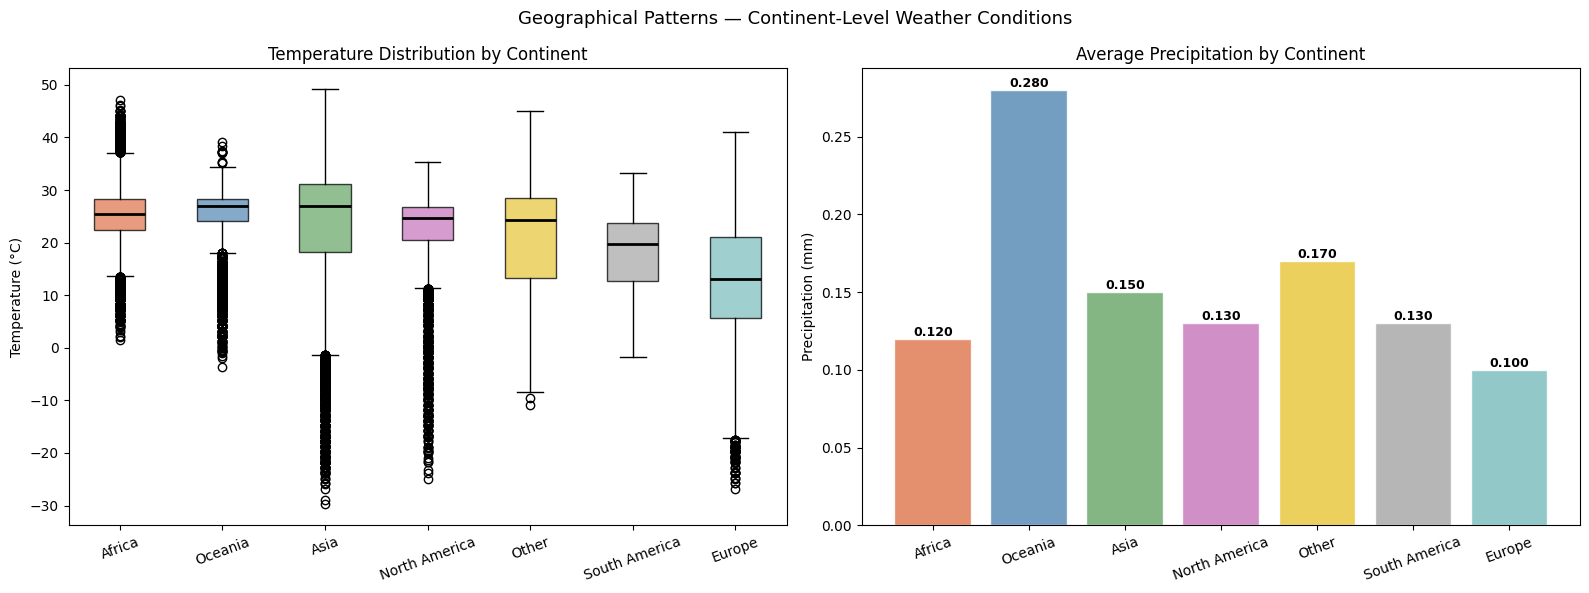

In [36]:
# TEMPERATURE AND PRECIPITATION DISTRIBUTION BY CONTINEN

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

continents_order = continent_stats.index.tolist()

# Box plot — temperature
data_by_continent = [
    analysis_df[analysis_df['continent'] == c]['temperature_celsius'].dropna().values
    for c in continents_order
]
bp = axes[0].boxplot(data_by_continent, labels=continents_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colors_cont = ['#e07b54','#5b8db8','#6daa6d','#c97bbf','#e8c842','#aaaaaa','#7fbfbf']
for patch, color in zip(bp['boxes'], colors_cont):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title('Temperature Distribution by Continent')
axes[0].set_ylabel('Temperature (°C)')
axes[0].tick_params(axis='x', rotation=20)

# Bar chart — avg precipitation
axes[1].bar(continents_order, continent_stats['avg_precip'],
            color=colors_cont[:len(continents_order)], alpha=0.85, edgecolor='white')
axes[1].set_title('Average Precipitation by Continent')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(continent_stats['avg_precip']):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Geographical Patterns — Continent-Level Weather Conditions', fontsize=13)
plt.tight_layout()
plt.show()

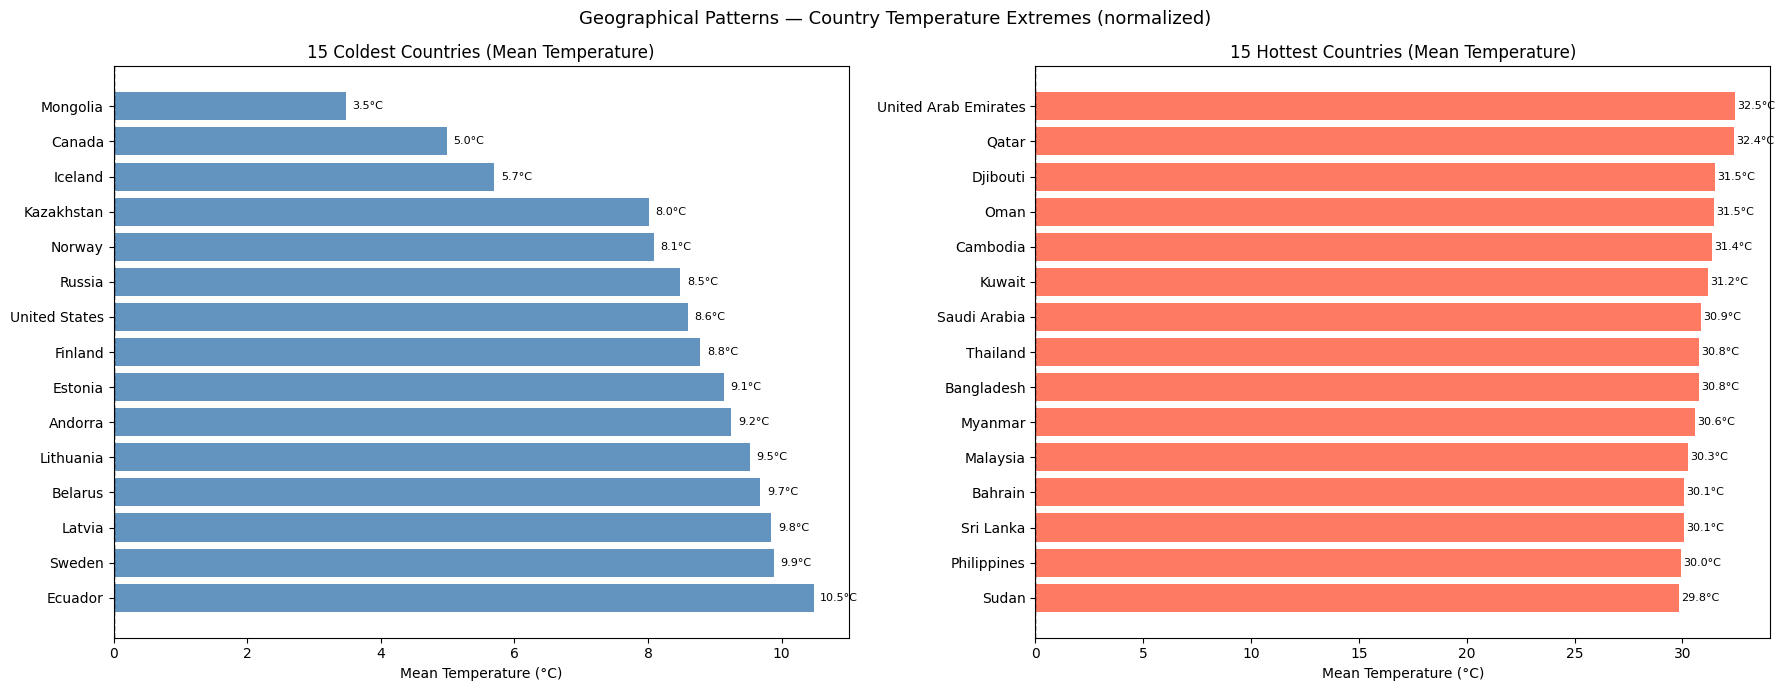

In [ ]:
# TOP BOTTOM CONTRIES BY MEAN TEMPERATURE

country_temp = (
    analysis_df[analysis_df['continent'] != 'Other']   # exclude unmapped noise
    .groupby('country')['temperature_celsius']
    .mean()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 15 coldest 
coldest = country_temp.head(15)
axes[0].barh(coldest.index, coldest.values, color='steelblue', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')   # zero reference line
axes[0].set_title('15 Coldest Countries (Mean Temperature)')
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].invert_yaxis()
for i, (country, v) in enumerate(coldest.items()):
    axes[0].text(v + 0.1 if v >= 0 else v - 0.1, i,
                 f'{v:.1f}°C', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)

# 15 hottest
hottest = country_temp.tail(15).sort_values(ascending=False)
axes[1].barh(hottest.index, hottest.values, color='tomato', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('15 Hottest Countries (Mean Temperature)')
axes[1].set_xlabel('Mean Temperature (°C)')
axes[1].invert_yaxis()
for i, (country, v) in enumerate(hottest.items()):
    axes[1].text(v + 0.1, i, f'{v:.1f}°C', va='center', ha='left', fontsize=8)

plt.suptitle('Geographical Patterns — Country Temperature Extremes (normalized)',
             fontsize=13)
plt.tight_layout()
plt.show()

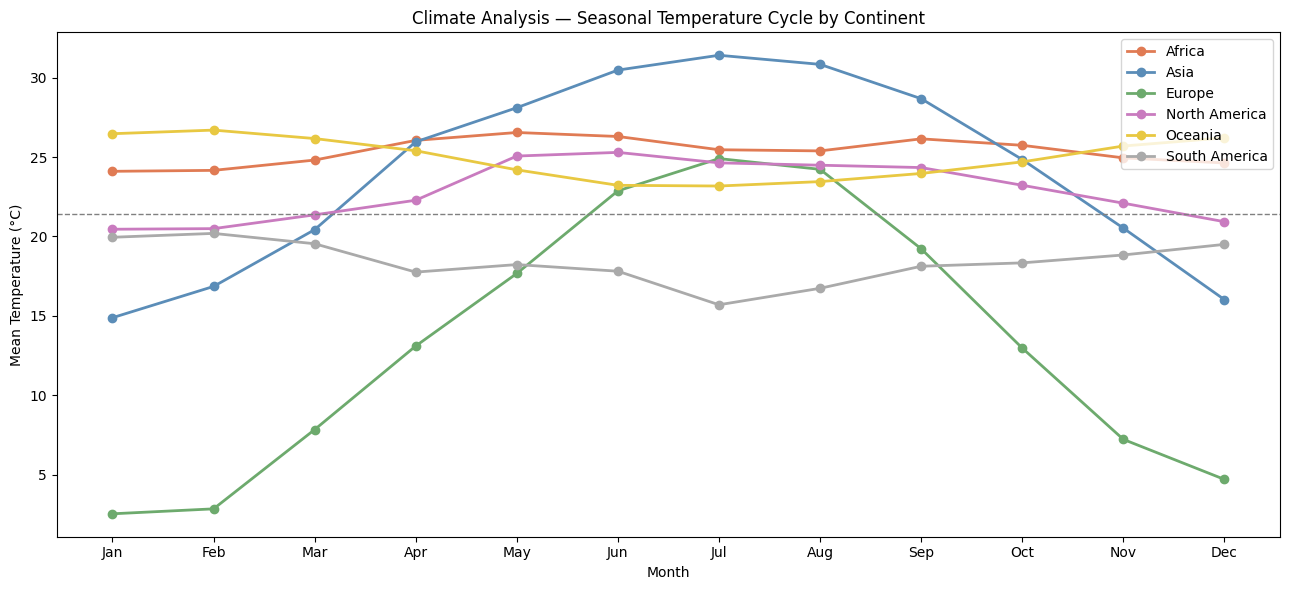

In [ ]:
# CLIMATE ANALYSIS Seasonal temperature cycle per continent 
# Long-term climate patterns and variations in different regions.

monthly_continent = (
    analysis_df[analysis_df['continent'] != 'Other']
    .groupby(['continent', 'month'])['temperature_celsius']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, (continent, grp) in enumerate(monthly_continent.groupby('continent')):
    grp_sorted = grp.sort_values('month')
    ax.plot(grp_sorted['month'], grp_sorted['temperature_celsius'],
            marker='o', linewidth=2, label=continent, color=colors_cont[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean Temperature (°C)')
ax.set_xlabel('Month')
ax.set_title('Climate Analysis — Seasonal Temperature Cycle by Continent')
ax.legend(loc='upper right')
ax.axhline(analysis_df['temperature_celsius'].mean(), color='gray',
           linestyle='--', linewidth=1, label='Global mean')
plt.tight_layout()
plt.show()

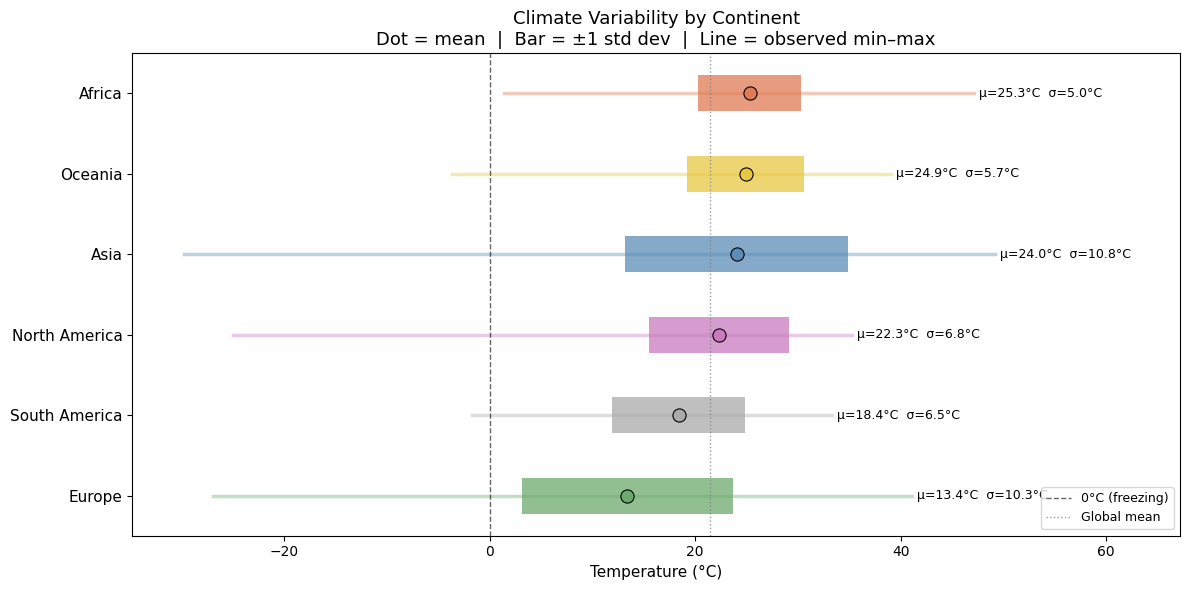

In [ ]:
# Climate variability: temperature std per continent 
# Higher std = more volatile climate; lower = stable (e.g. tropical regions).

climate_var = (
    analysis_df[analysis_df['continent'] != 'Other']
    .groupby('continent')['temperature_celsius']
    .agg(mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('mean', ascending=True)   # sort by mean so axis reads cold→hot
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

cont_colors_map = {
    'Africa':        '#e07b54',
    'Asia':          '#5b8db8',
    'Europe':        '#6daa6d',
    'North America': '#c97bbf',
    'Oceania':       '#e8c842',
    'South America': '#aaaaaa',
}

for i, row in climate_var.iterrows():
    color = cont_colors_map.get(row['continent'], '#888888')

    # min–max whisker (full observed range)
    ax.plot([row['min'], row['max']], [i, i],
            color=color, linewidth=2.5, alpha=0.4, zorder=1)

    # ±1 std bar
    ax.barh(i, row['std'] * 2,
            left=row['mean'] - row['std'],
            height=0.45, color=color, alpha=0.75, zorder=2)

    # mean dot
    ax.scatter(row['mean'], i, color=color, s=90, zorder=3,
               edgecolors='black', linewidths=0.8)

    # annotate mean and std
    ax.text(row['max'] + 0.5, i,
            f"μ={row['mean']:.1f}°C  σ={row['std']:.1f}°C",
            va='center', fontsize=9)

# Reference lines
ax.axvline(0,  color='black',  linewidth=1.0, linestyle='--', alpha=0.6, label='0°C (freezing)')
ax.axvline(analysis_df['temperature_celsius'].mean(),
           color='gray', linewidth=1.0, linestyle=':', alpha=0.8, label='Global mean')

ax.set_yticks(range(len(climate_var)))
ax.set_yticklabels(climate_var['continent'], fontsize=11)
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_title(
    'Climate Variability by Continent\n'
    'Dot = mean  |  Bar = ±1 std dev  |  Line = observed min–max',
    fontsize=13
)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(climate_var['min'].min() - 5, climate_var['max'].max() + 18)

plt.tight_layout()
plt.show()